# Final Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

**Project:** Analyzing the Impact of Recession on Automobile Sales

This notebook completes Tasks 1.1–1.9.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

DATA_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/"
    "historical_automobile_sales.csv"
)

try:
    df = pd.read_csv(DATA_URL)
    print("Loaded the official IBM Skills Network dataset.")
except Exception:
    df = pd.read_csv("historical_automobile_sales.csv")
    print("Loaded the local fallback dataset.")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.head()


Loaded the local fallback dataset.


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,99.38,0.9,32958.26,2.424046e+07,31.88,14026.18,2.18,6.14,527.88,ExecutiveCar,City_1
1,1980-01-31,1980,Jan,1,99.38,0.9,25317.56,1.862390e+08,31.88,14026.18,3.28,6.14,1435.58,MediumFamilyCar,City_1
2,1980-01-31,1980,Jan,1,99.38,0.9,19901.79,1.043567e+08,31.88,14026.18,1.64,6.14,1615.05,SmallFamilyCar,City_1
3,1980-01-31,1980,Jan,1,99.38,0.9,30232.89,1.461730e+08,31.88,14026.18,2.45,6.14,758.98,Sports,City_1
4,1980-01-31,1980,Jan,1,99.38,0.9,14955.26,2.496301e+08,31.88,14026.18,2.35,6.14,1725.28,SuperMiniCar,City_1


## TASK 1.1 — Automobile Sales by Year

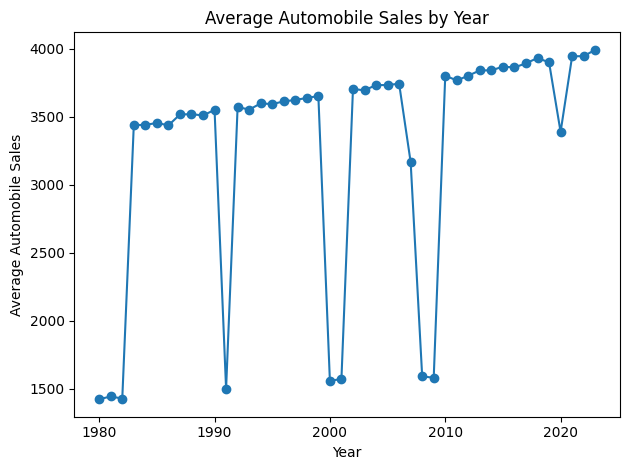

In [2]:
yearly_sales = df.groupby("Year")["Automobile_Sales"].mean()
ax = yearly_sales.plot(kind="line", marker="o", title="Average Automobile Sales by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()


## TASK 1.2 — Vehicle-Type Trends During Recession Periods

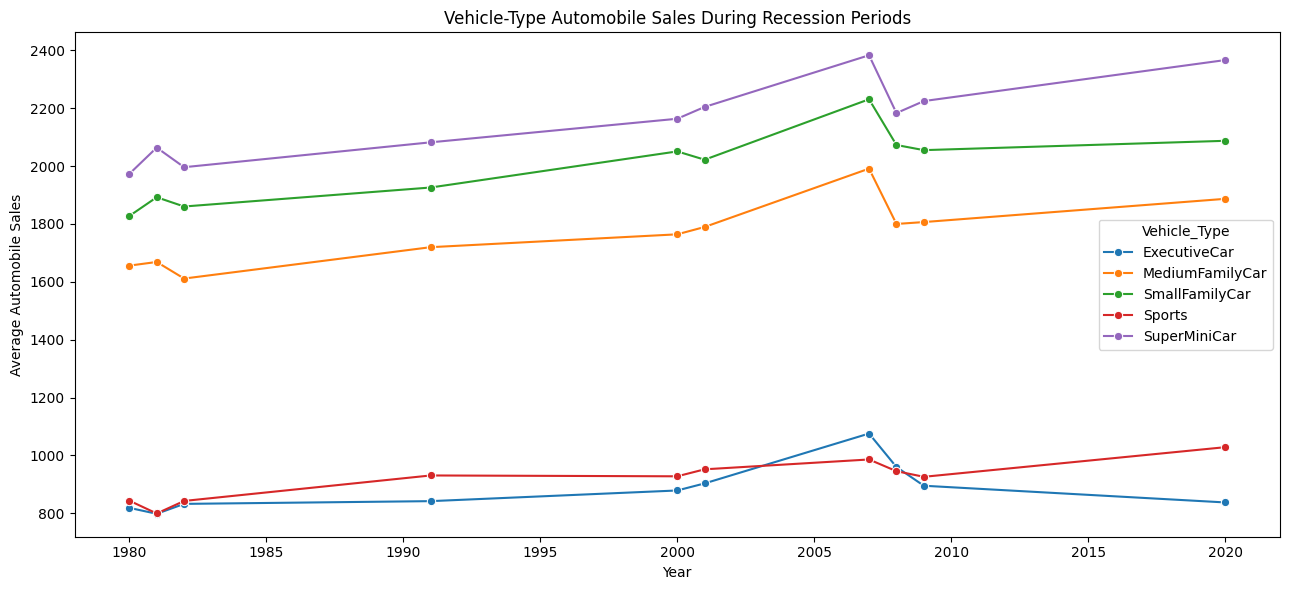

In [3]:
recession = df[df["Recession"] == 1]
trend = recession.groupby(["Year", "Vehicle_Type"])["Automobile_Sales"].mean().reset_index()

plt.figure(figsize=(13, 6))
sns.lineplot(data=trend, x="Year", y="Automobile_Sales", hue="Vehicle_Type", marker="o")
plt.title("Vehicle-Type Automobile Sales During Recession Periods")
plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()


## TASK 1.3 — Seaborn Recession vs Non-Recession Comparison

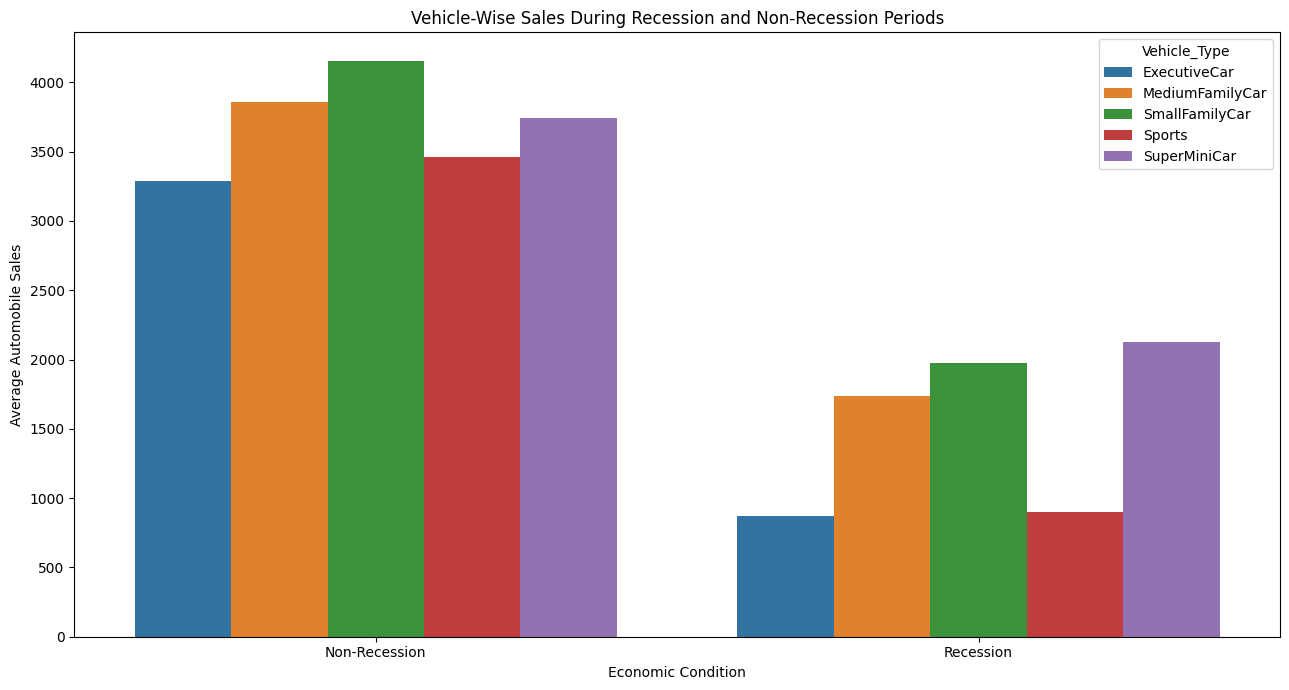

In [4]:
avg_sales = df.groupby(["Recession", "Vehicle_Type"])["Automobile_Sales"].mean().reset_index()
avg_sales["Economic_Condition"] = avg_sales["Recession"].map({0: "Non-Recession", 1: "Recession"})

plt.figure(figsize=(13, 7))
sns.barplot(data=avg_sales, x="Economic_Condition", y="Automobile_Sales", hue="Vehicle_Type")
plt.title("Vehicle-Wise Sales During Recession and Non-Recession Periods")
plt.xlabel("Economic Condition")
plt.ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()


## TASK 1.4 — GDP During Recession vs Non-Recession

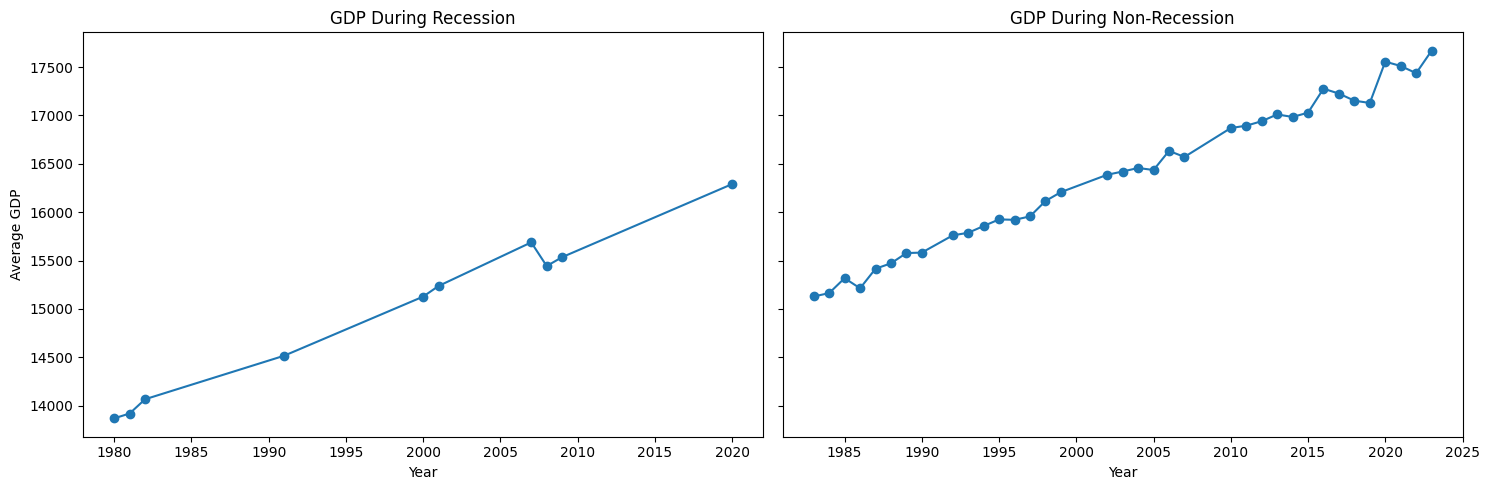

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

df[df["Recession"] == 1].groupby("Year")["GDP"].mean().plot(
    ax=axes[0], marker="o", title="GDP During Recession"
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")

df[df["Recession"] == 0].groupby("Year")["GDP"].mean().plot(
    ax=axes[1], marker="o", title="GDP During Non-Recession"
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average GDP")

plt.tight_layout()
plt.show()


## TASK 1.5 — Bubble Plot for Seasonality

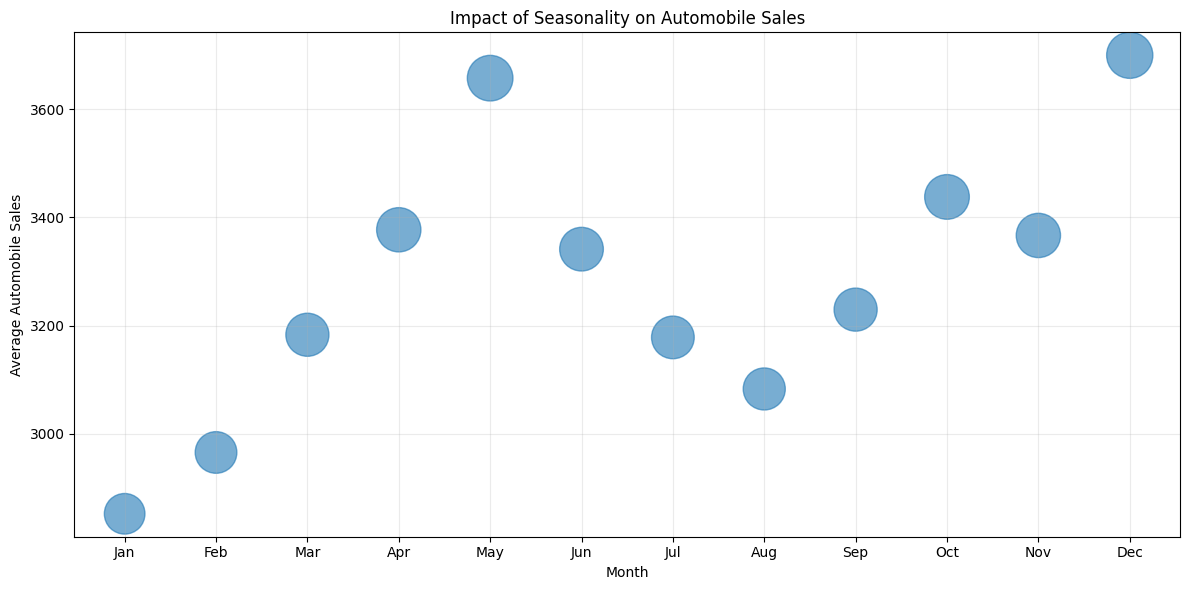

In [6]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
tmp = df.copy()
tmp["Month"] = pd.Categorical(tmp["Month"], categories=month_order, ordered=True)

bubble = tmp.groupby("Month", observed=False).agg(
    Automobile_Sales=("Automobile_Sales", "mean"),
    Seasonality_Weight=("Seasonality_Weight", "mean")
).reset_index()

plt.figure(figsize=(12, 6))
plt.scatter(
    bubble["Month"].astype(str),
    bubble["Automobile_Sales"],
    s=(bubble["Seasonality_Weight"] + 0.05) * 900,
    alpha=0.6
)
plt.title("Impact of Seasonality on Automobile Sales")
plt.xlabel("Month")
plt.ylabel("Average Automobile Sales")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## TASK 1.6 — Price vs Sales During Recession

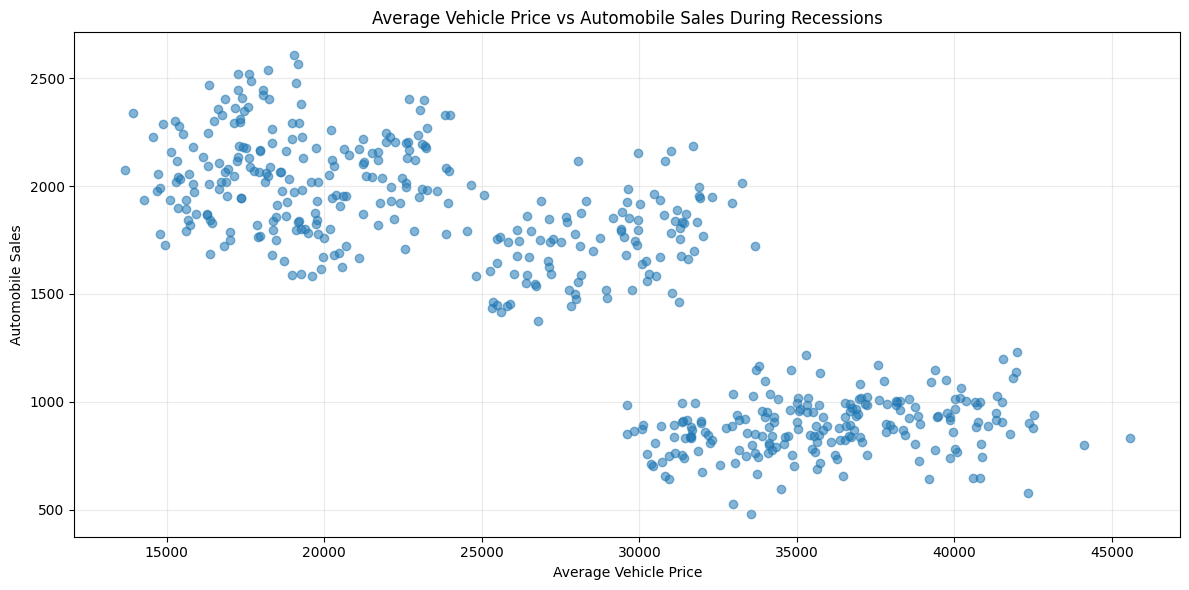

In [7]:
rec_price = df[df["Recession"] == 1]
plt.figure(figsize=(12, 6))
plt.scatter(rec_price["Price"], rec_price["Automobile_Sales"], alpha=0.55)
plt.title("Average Vehicle Price vs Automobile Sales During Recessions")
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## TASK 1.7 — Advertising Expenditure During Recession vs Non-Recession

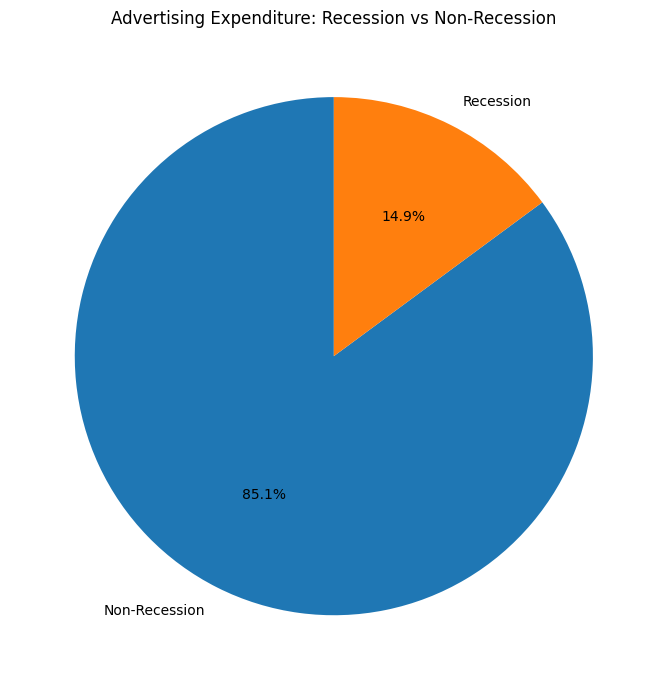

In [8]:
ad_share = df.groupby("Recession")["Advertising_Expenditure"].sum()
plt.figure(figsize=(7, 7))
plt.pie(ad_share, labels=["Non-Recession", "Recession"], autopct="%1.1f%%", startangle=90)
plt.title("Advertising Expenditure: Recession vs Non-Recession")
plt.tight_layout()
plt.show()


## TASK 1.8 — Advertisement Expenditure by Vehicle Type During Recession

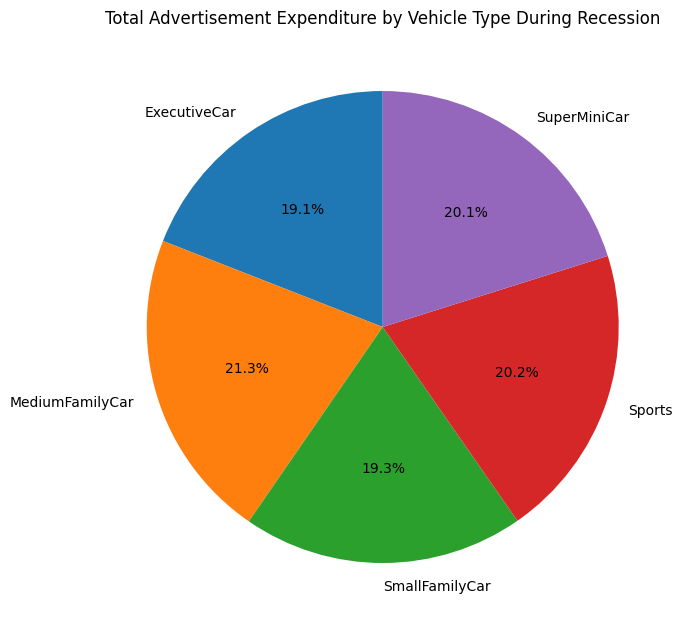

In [9]:
vehicle_ad_rec = df[df["Recession"] == 1].groupby("Vehicle_Type")["Advertising_Expenditure"].sum()
plt.figure(figsize=(7, 7))
plt.pie(vehicle_ad_rec, labels=vehicle_ad_rec.index, autopct="%1.1f%%", startangle=90)
plt.title("Total Advertisement Expenditure by Vehicle Type During Recession")
plt.tight_layout()
plt.show()


## TASK 1.9 — Unemployment Rate, Vehicle Type and Sales During Recession

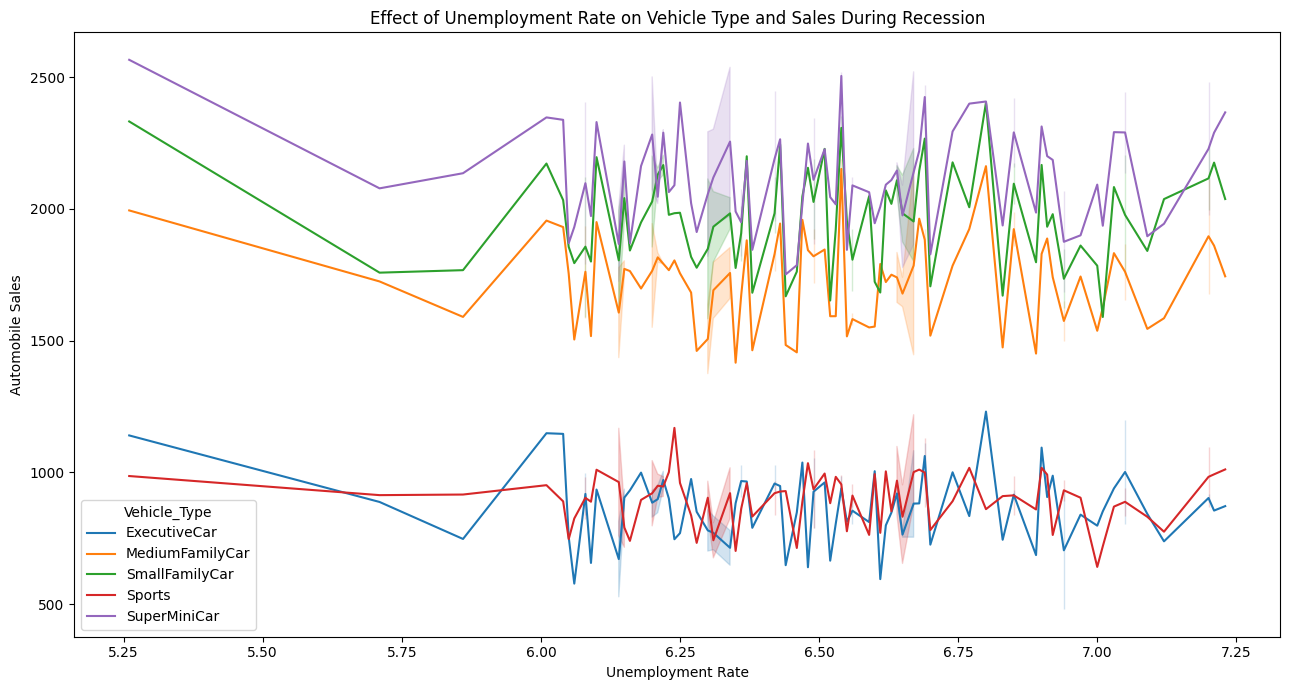

In [10]:
recession_df = df[df["Recession"] == 1]
plt.figure(figsize=(13, 7))
sns.lineplot(
    data=recession_df,
    x="unemployment_rate",
    y="Automobile_Sales",
    hue="Vehicle_Type"
)
plt.title("Effect of Unemployment Rate on Vehicle Type and Sales During Recession")
plt.xlabel("Unemployment Rate")
plt.ylabel("Automobile Sales")
plt.tight_layout()
plt.show()


## Folium — Interactive Geographic Visualization

This section creates an interactive Folium map using representative city coordinates for the `City` labels in the provided local fallback dataset.

In [11]:
city_points = {
    "City_1": (40.7128, -74.0060), "City_2": (41.8781, -87.6298),
    "City_3": (34.0522, -118.2437), "City_4": (29.7604, -95.3698),
    "City_5": (33.4484, -112.0740), "City_6": (39.9526, -75.1652),
    "City_7": (25.7617, -80.1918), "City_8": (47.6062, -122.3321)
}
city_sales = df[df["Recession"] == 1].groupby("City")["Automobile_Sales"].mean().reset_index()

m = folium.Map(location=[39.0, -96.0], zoom_start=4)
for _, row in city_sales.iterrows():
    if row["City"] in city_points:
        folium.Marker(
            location=city_points[row["City"]],
            popup=f'{row["City"]}: {row["Automobile_Sales"]:.0f} average sales',
            tooltip=row["City"]
        ).add_to(m)

m.save("automobile_sales_folium_map.html")
m


### Submission checklist

• Tasks 1.1–1.9 are present.
• Matplotlib/Pandas/Seaborn/Folium are used.
• The notebook is designed to run with the official IBM dataset and a local fallback CSV.